In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [20]:
def show_collection(images, titles, cols=3):
    rows = (len(images) + cols - 1) // cols
    plt.figure(figsize=(5 * cols, 5 * rows))
    
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

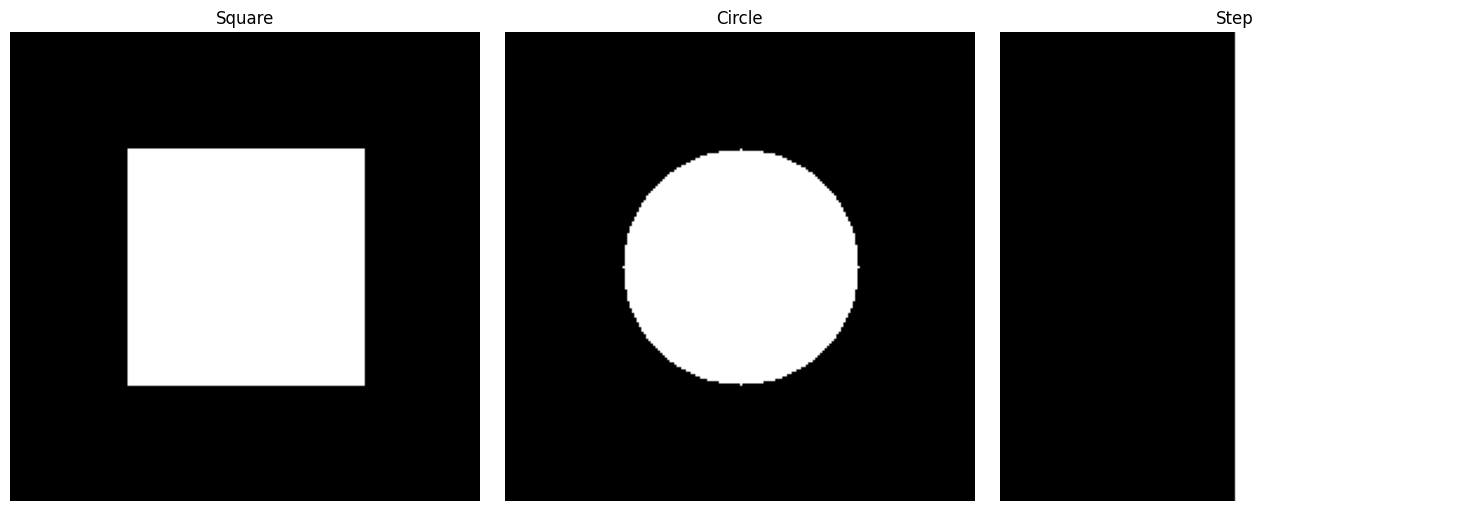

In [21]:
img_square = np.zeros((200, 200), dtype=np.uint8)
img_circle = np.zeros((200, 200), dtype=np.uint8)
img_step = np.zeros((200, 200), dtype=np.uint8)

cv2.rectangle(img_square, (50, 50), (150, 150), 255, -1)
cv2.circle(img_circle, (100, 100), 50, 255, -1)

img_step[:, :100] = 50
img_step[:, 100:] = 220

show_collection([img_square, img_circle, img_step], ["Square", "Circle", "Step"])

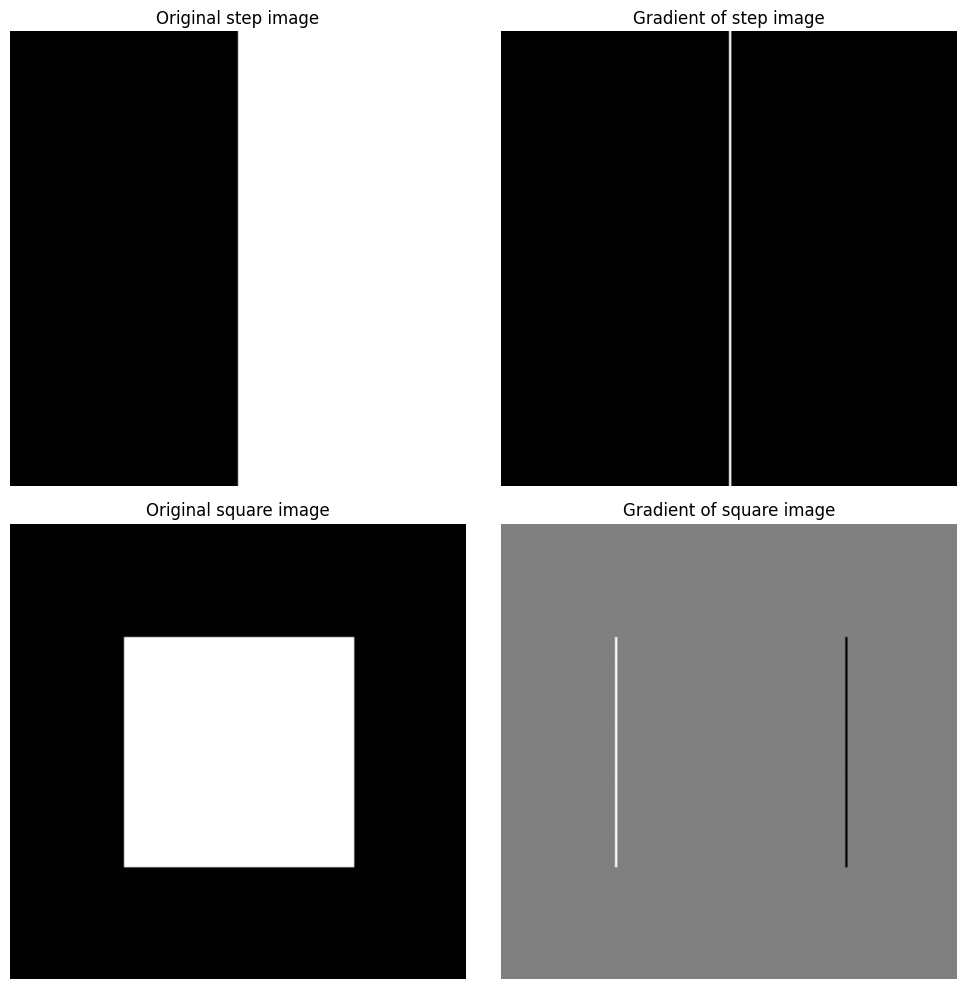

In [24]:
kernel_x = np.array([[-1, 1]], dtype=np.float32)

grad_step = cv2.filter2D(img_step, cv2.CV_64F, kernel_x)
grad_square = cv2.filter2D(img_square, cv2.CV_64F, kernel_x)

show_collection([img_step, grad_step, img_square, grad_square], ["Original step image", "Gradient of step image", "Original square image",
                                                                 "Gradient of square image"], cols=2)

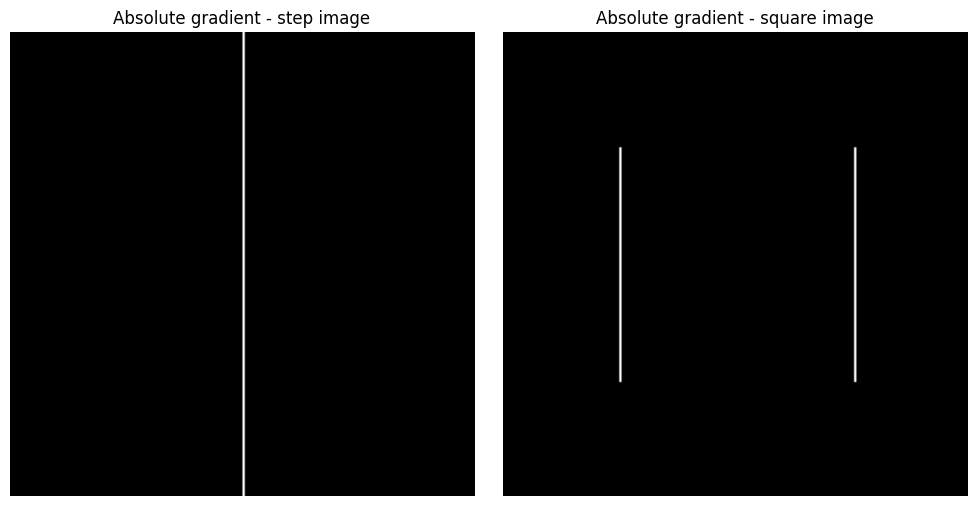

In [23]:
grad_square_abs = np.abs(grad_square).astype(np.uint8)
grad_step_abs = np.abs(grad_step).astype(np.uint8)

show_collection(
    images=[grad_step_abs, grad_square_abs], 
    titles=["Absolute gradient - step image", "Absolute gradient - square image"],
    cols=2
)